# Insights about the dataset

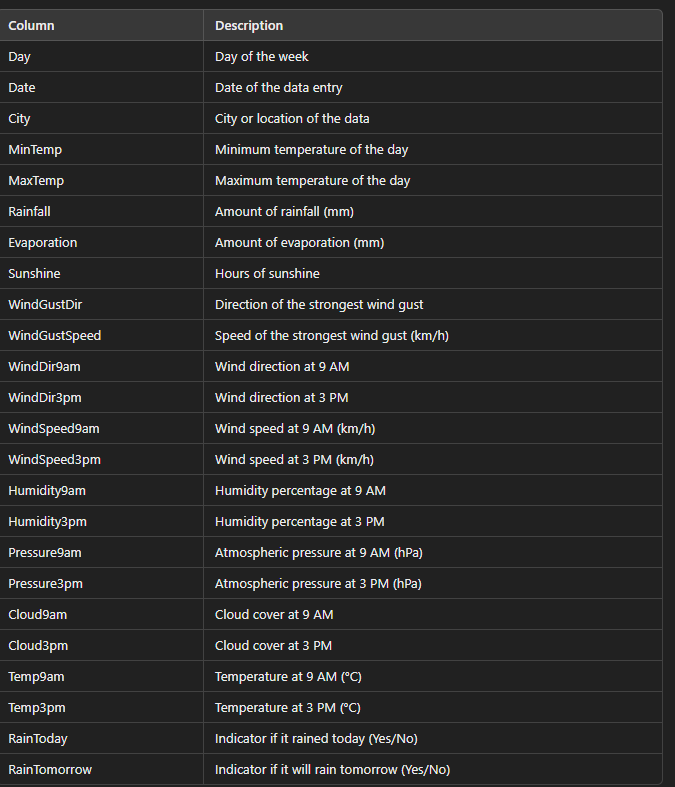

# Evaluating features importance

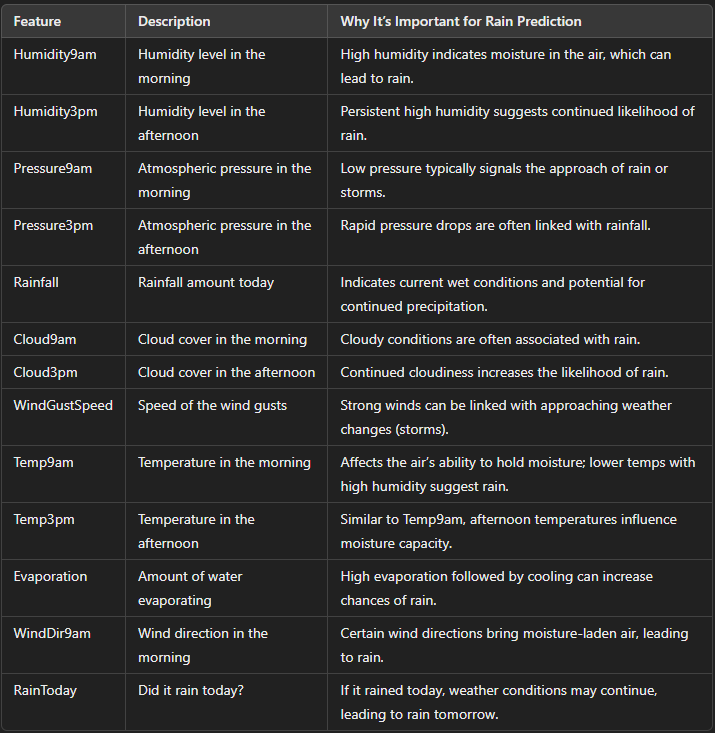

# Necessary imports

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [66]:
rain_df = pd.read_csv('rain-prediction-challenge/train.csv')
print(rain_df.head())


   Day        Date            City  MinTemp  MaxTemp  Rainfall  Evaporation  \
0    0  2010-01-01         Algiers     19.4     31.9       5.0          NaN   
1    1  2010-01-02           Setif     18.6     29.1      12.4          NaN   
2    2  2010-01-03  Sidi Bel Abbes     12.2     29.7       0.0          NaN   
3    3  2010-01-04          Skikda     14.8     32.8       0.0          NaN   
4    4  2010-01-05          Skikda     15.0     35.8       0.0          NaN   

   Sunshine WindGustDir  WindGustSpeed  ... Humidity9am Humidity3pm  \
0       NaN         NNE           39.0  ...        70.0        40.0   
1       NaN           W           56.0  ...        88.0        48.0   
2       NaN           W           30.0  ...        57.0        32.0   
3       NaN          SW           30.0  ...        55.0        24.0   
4       NaN           W           46.0  ...        46.0        13.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1012.2    

In [67]:
description_full = rain_df.describe(include='all')
print(description_full)

                 Day        Date    City       MinTemp       MaxTemp  \
count   76672.000000       76672   76672  76453.000000  76478.000000   
unique           NaN        1737      10           NaN           NaN   
top              NaN  2010-01-01  Skikda           NaN           NaN   
freq             NaN          45    7864           NaN           NaN   
mean    38335.500000         NaN     NaN     11.894520     22.833249   
std     22133.444257         NaN     NaN      6.361629      6.845794   
min         0.000000         NaN     NaN     -8.200000     -4.100000   
25%     19167.750000         NaN     NaN      7.400000     17.800000   
50%     38335.500000         NaN     NaN     11.700000     22.300000   
75%     57503.250000         NaN     NaN     16.500000     27.600000   
max     76671.000000         NaN     NaN     31.400000     48.100000   

            Rainfall   Evaporation      Sunshine WindGustDir  WindGustSpeed  \
count   76672.000000  46996.000000  44312.000000       7

In [68]:
rain_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76672 entries, 0 to 76671
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Day            76672 non-null  int64  
 1   Date           76672 non-null  object 
 2   City           76672 non-null  object 
 3   MinTemp        76453 non-null  float64
 4   MaxTemp        76478 non-null  float64
 5   Rainfall       76672 non-null  float64
 6   Evaporation    46996 non-null  float64
 7   Sunshine       44312 non-null  float64
 8   WindGustDir    71517 non-null  object 
 9   WindGustSpeed  71554 non-null  float64
 10  WindDir9am     70965 non-null  object 
 11  WindDir3pm     75134 non-null  object 
 12  WindSpeed9am   76081 non-null  float64
 13  WindSpeed3pm   75872 non-null  float64
 14  Humidity9am    75811 non-null  float64
 15  Humidity3pm    75834 non-null  float64
 16  Pressure9am    69106 non-null  float64
 17  Pressure3pm    69081 non-null  float64
 18  Cloud9

In [69]:
rain_df['Date'] = pd.to_datetime(rain_df['Date'])
rain_df.set_index('Date', inplace=True)


### Line Chart for Temperature & Pressure

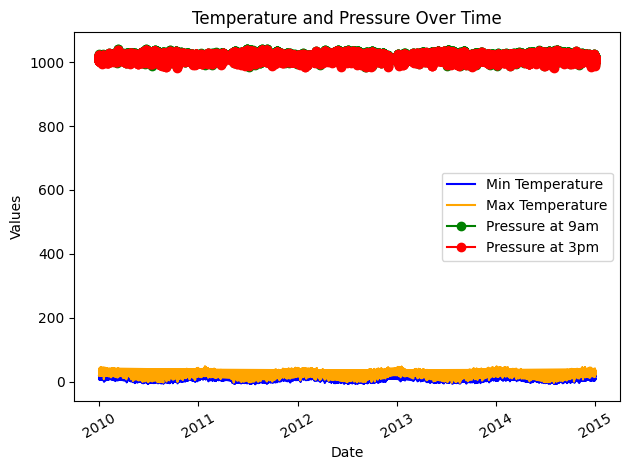

In [70]:
plt.plot(rain_df['MinTemp'], label='Min Temperature', color='blue')
plt.plot(rain_df['MaxTemp'], label='Max Temperature', color='orange')
plt.plot(rain_df['Pressure9am'], label='Pressure at 9am', color='green', marker='o')
plt.plot(rain_df['Pressure3pm'], label='Pressure at 3pm', color='red', marker='o')
plt.title('Temperature and Pressure Over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

 low pressure -> precipitation ( increased raining ) 
 
 temperature -> influences humidity levels -> rainfall

conclusion : temp drop + pressure decrease => storm approaching

### Relationship between Humidity and Rainfall

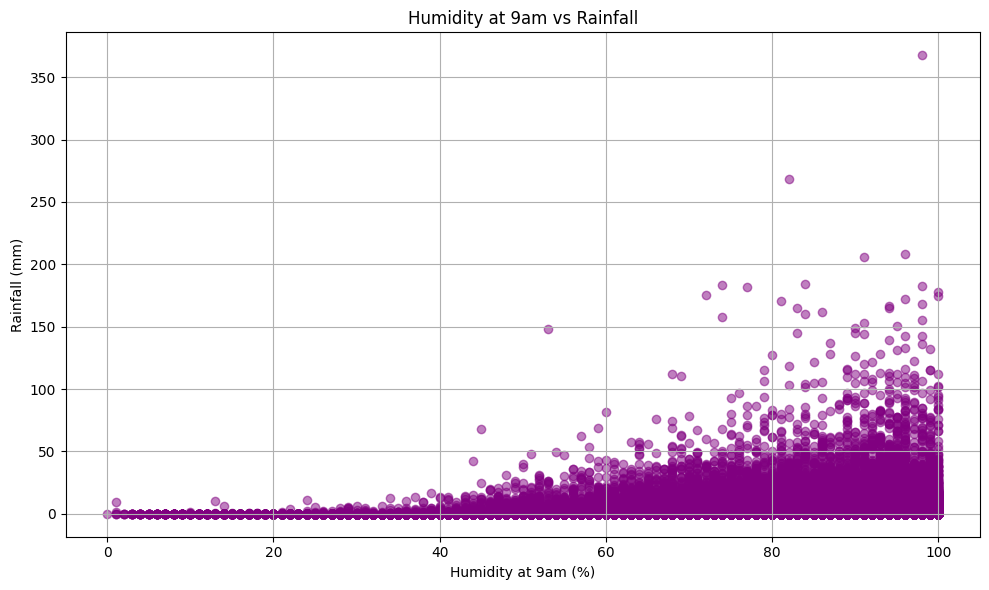

In [71]:
plt.figure(figsize=(10, 6))
plt.scatter(rain_df['Humidity9am'], rain_df['Rainfall'], alpha=0.5, color='purple')
plt.title('Humidity at 9am vs Rainfall')
plt.xlabel('Humidity at 9am (%)')
plt.ylabel('Rainfall (mm)')
plt.grid()
plt.tight_layout()
plt.show()

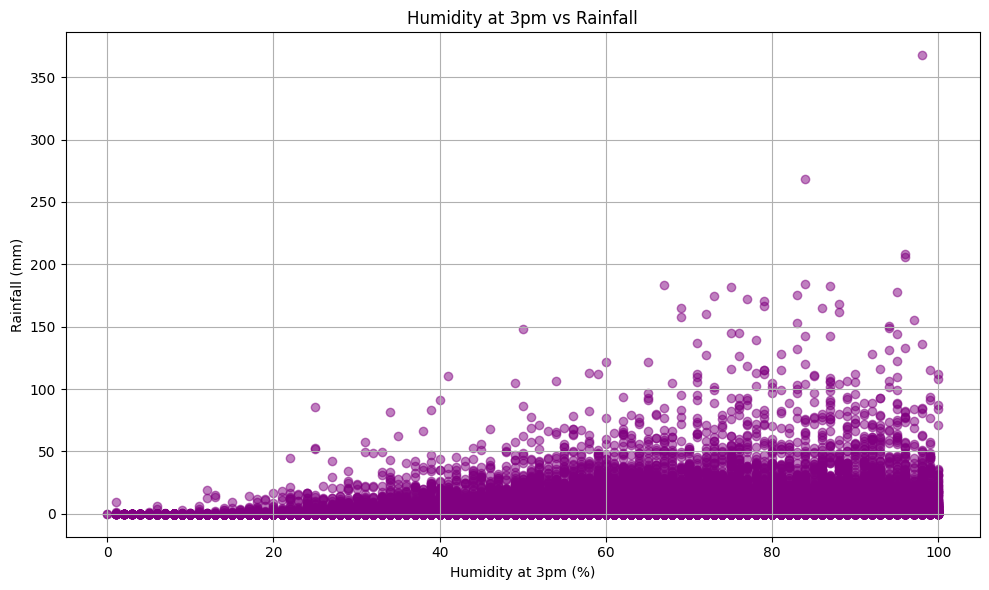

In [72]:
plt.figure(figsize=(10, 6))
plt.scatter(rain_df['Humidity3pm'], rain_df['Rainfall'], alpha=0.5, color='purple')
plt.title('Humidity at 3pm vs Rainfall')
plt.xlabel('Humidity at 3pm (%)')
plt.ylabel('Rainfall (mm)')
plt.grid()
plt.tight_layout()
plt.show()

correlation between humidity levels at 9am/3pm and rainfall

### Heatmap for Correlation Between Variables

In [73]:
# Select only numeric columns
numeric_df = rain_df.select_dtypes(include=['float64', 'int64'])

# Compute the correlation matrix
correlation_matrix = numeric_df.corr()

# Display the correlation matrix
print(correlation_matrix)



                    Day   MinTemp   MaxTemp  Rainfall  Evaporation  Sunshine  \
Day            1.000000  0.050209  0.071217 -0.017403     0.058415  0.080367   
MinTemp        0.050209  1.000000  0.727878  0.113049     0.467076  0.051789   
MaxTemp        0.071217  0.727878  1.000000 -0.071744     0.601336  0.457834   
Rainfall      -0.017403  0.113049 -0.071744  1.000000    -0.073377 -0.234647   
Evaporation    0.058415  0.467076  0.601336 -0.073377     1.000000  0.369367   
Sunshine       0.080367  0.051789  0.457834 -0.234647     0.369367  1.000000   
WindGustSpeed  0.063133  0.186482  0.069610  0.138817     0.216690 -0.020896   
WindSpeed9am   0.087284  0.196041  0.027873  0.093308     0.215435  0.027876   
WindSpeed3pm   0.072440  0.192101  0.065594  0.058868     0.140959  0.066230   
Humidity9am   -0.123947 -0.220226 -0.495541  0.228160    -0.519448 -0.498068   
Humidity3pm   -0.060507  0.036680 -0.488953  0.258406    -0.397758 -0.634444   
Pressure9am   -0.101489 -0.459129 -0.337

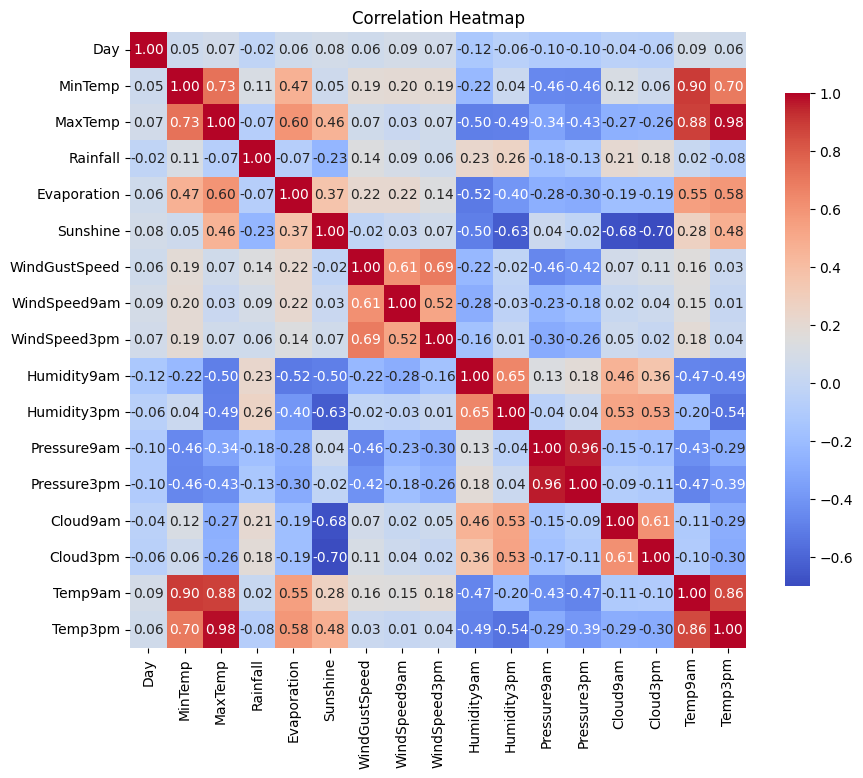

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create a heatmap
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})

# Set the title
plt.title('Correlation Heatmap')

# Show the plot
plt.show()


heatmap : show correlation between vars, values around diagonal are symetric

1 : shows strong corr , as the 1st var increases, the 2nd increases

-1 : shows strong corr, as the 1st var increases, the 2nd decreases

0 : no corr

### Bar Plot for Cloud Cover at 9am vs Rainfall

C:\Users\Morsi Store DZ\AppData\Local\Temp\ipykernel_3660\252236804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cloud9am', y='Rainfall', data=cloud_rain_data, palette='Blues')


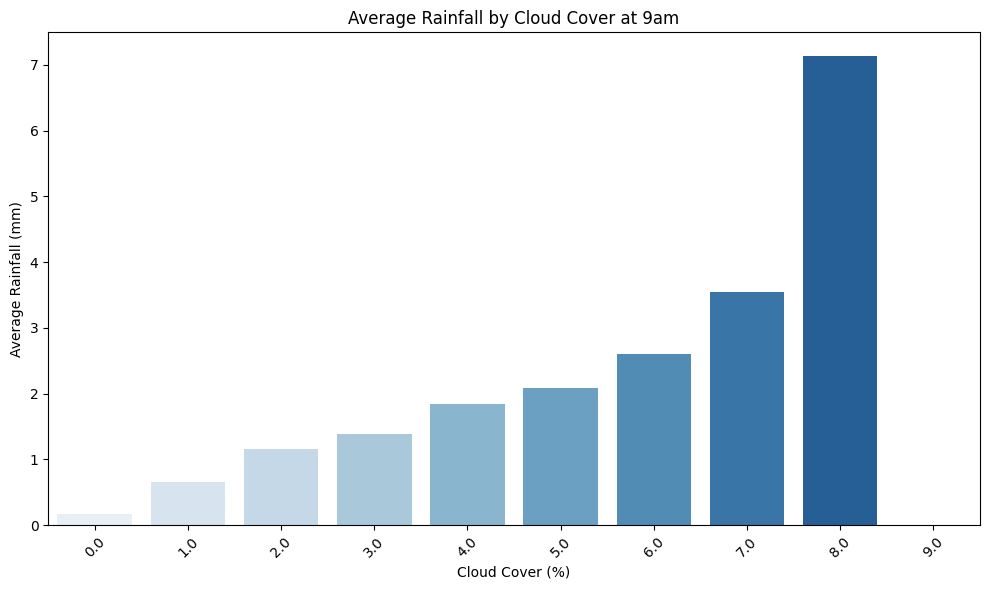

In [75]:
cloud_rain_data = rain_df.groupby('Cloud9am')['Rainfall'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cloud9am', y='Rainfall', data=cloud_rain_data, palette='Blues')
plt.title('Average Rainfall by Cloud Cover at 9am')
plt.xlabel('Cloud Cover (%)')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Bar Plot for Cloud Cover at 3pm vs Rainfall

C:\Users\Morsi Store DZ\AppData\Local\Temp\ipykernel_3660\817420341.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Cloud3pm', y='Rainfall', data=cloud_rain_data, palette='Reds')


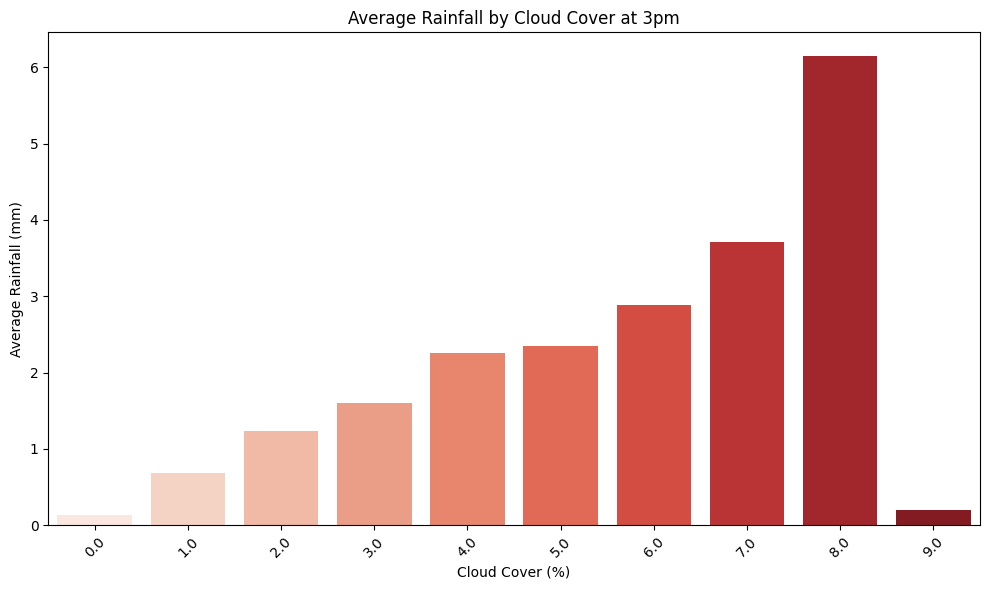

In [76]:
cloud_rain_data = rain_df.groupby('Cloud3pm')['Rainfall'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Cloud3pm', y='Rainfall', data=cloud_rain_data, palette='Reds')
plt.title('Average Rainfall by Cloud Cover at 3pm')
plt.xlabel('Cloud Cover (%)')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###  Stacked Area Chart

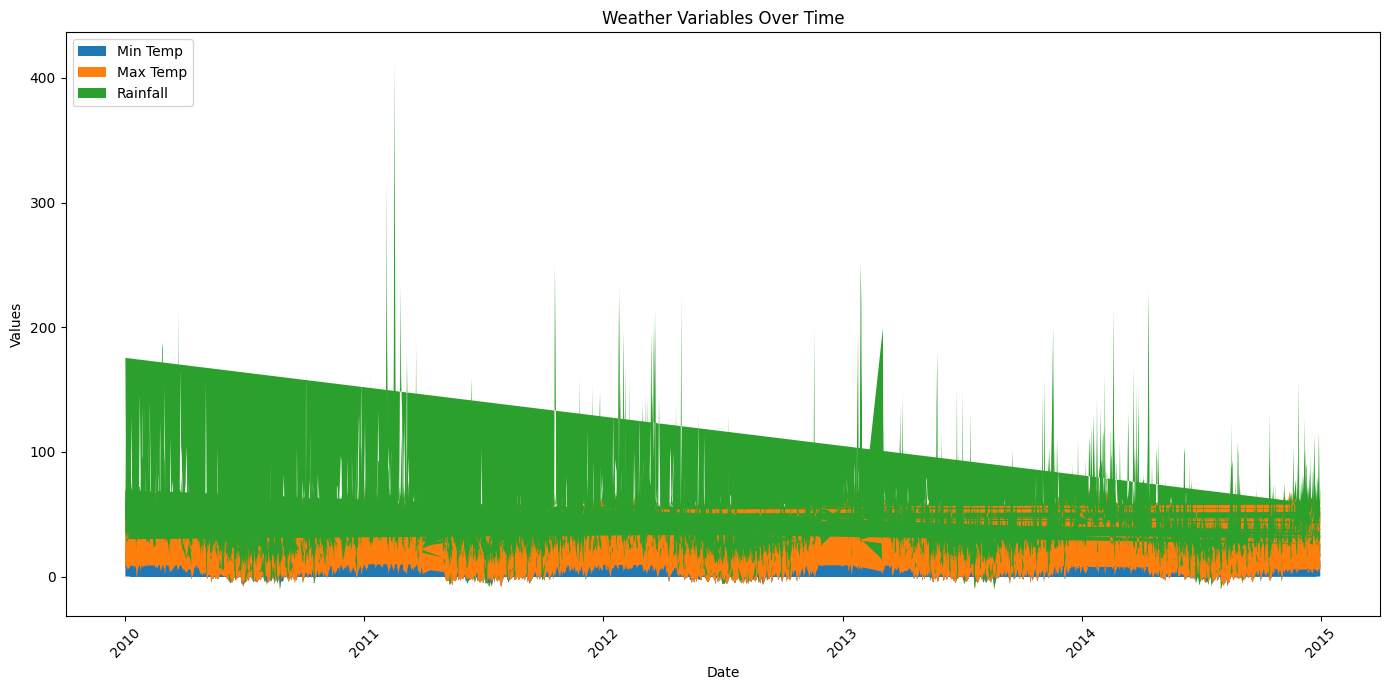

In [77]:
plt.figure(figsize=(14, 7))
plt.stackplot(rain_df.index, rain_df['MinTemp'], rain_df['MaxTemp'], rain_df['Rainfall'], labels=['Min Temp', 'Max Temp', 'Rainfall'])
plt.title('Weather Variables Over Time')
plt.xlabel('Date')
plt.ylabel('Values')
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


###  Histograms for Distribution

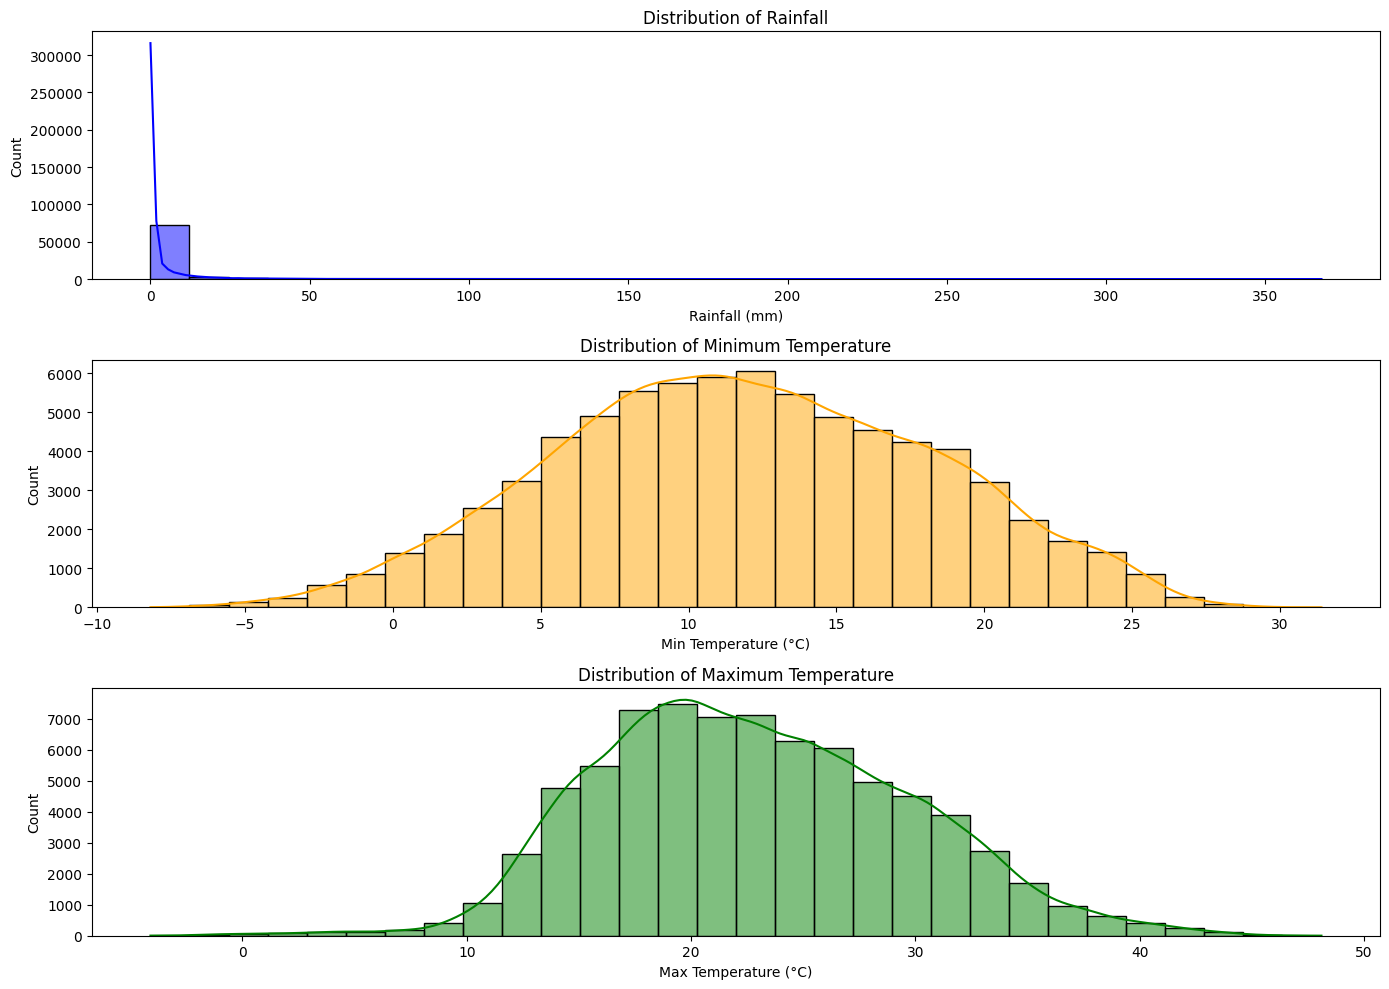

In [78]:
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
sns.histplot(rain_df['Rainfall'], bins=30, kde=True, color='blue')
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')

plt.subplot(3, 1, 2)
sns.histplot(rain_df['MinTemp'], bins=30, kde=True, color='orange')
plt.title('Distribution of Minimum Temperature')
plt.xlabel('Min Temperature (°C)')

plt.subplot(3, 1, 3)
sns.histplot(rain_df['MaxTemp'], bins=30, kde=True, color='green')
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Max Temperature (°C)')

plt.tight_layout()
plt.show()


lower values (e.g., 0-10 mm), it may indicate that rainfall events are infrequent or light..

moderate climate , stable temp range 10C-15C and 20 as max


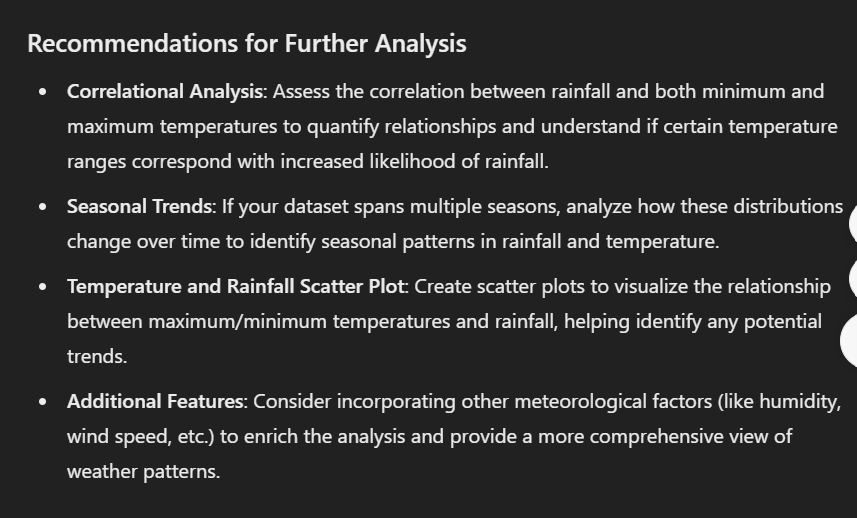

In [79]:
print(rain_df.columns)

Index(['Day', 'City', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')


In [80]:
print(rain_df['Day'])

Date
2010-01-01        0
2010-01-02        1
2010-01-03        2
2010-01-04        3
2010-01-05        4
              ...  
2014-12-27    76667
2014-12-28    76668
2014-12-29    76669
2014-12-30    76670
2014-12-31    76671
Name: Day, Length: 76672, dtype: int64


### clasify the for seasons

In [81]:
def classify_seasons(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    elif month in [9, 10, 11]:
        return "Autumn"
    
rain_df['Day']=pd.to_datetime(rain_df['Day'], errors='coerce')
rain_df['Month'] = rain_df['Day'].dt.month
rain_df['Season'] = rain_df['Month'].apply(classify_seasons)

print(rain_df['Season'])

Date
2010-01-01    Winter
2010-01-02    Winter
2010-01-03    Winter
2010-01-04    Winter
2010-01-05    Winter
               ...  
2014-12-27    Winter
2014-12-28    Winter
2014-12-29    Winter
2014-12-30    Winter
2014-12-31    Winter
Name: Season, Length: 76672, dtype: object


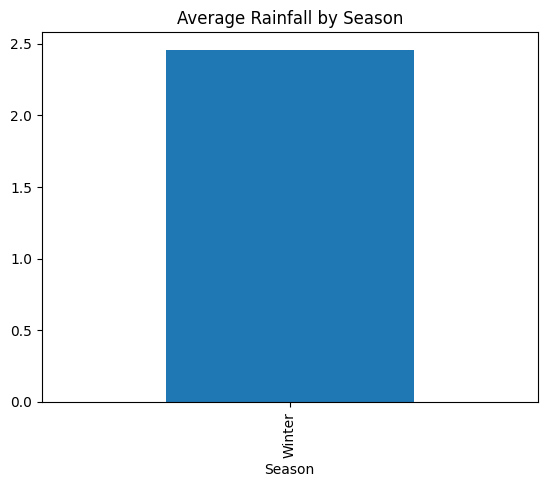

In [82]:
rainfall_by_season = rain_df.groupby('Season')['Rainfall'].mean()
rainfall_by_season.plot(kind='bar', title='Average Rainfall by Season')
plt.show()


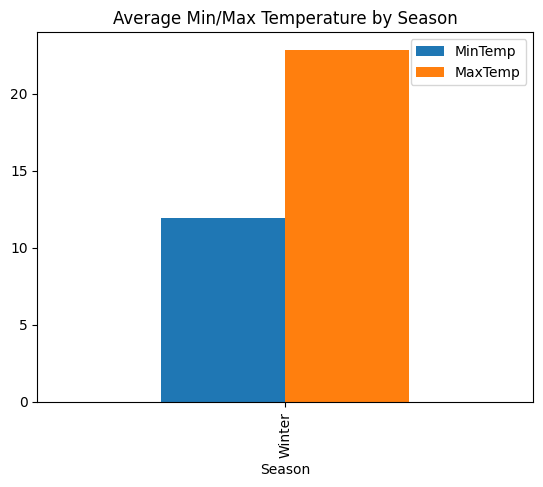

In [83]:
temperature_by_season = rain_df.groupby('Season')[['MinTemp', 'MaxTemp']].mean()
temperature_by_season.plot(kind='bar', title='Average Min/Max Temperature by Season')
plt.show()


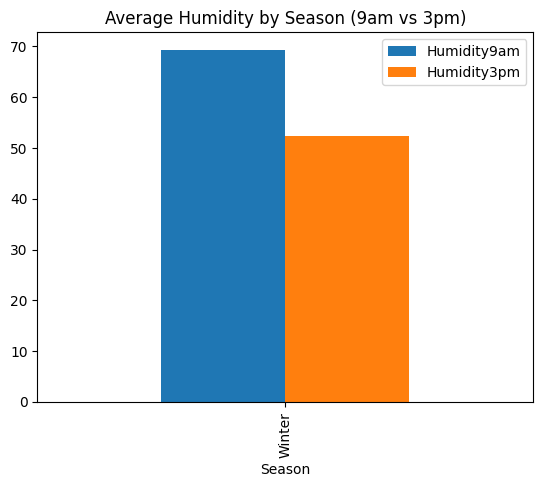

In [84]:
humidity_by_season = rain_df.groupby('Season')[['Humidity9am', 'Humidity3pm']].mean()
humidity_by_season.plot(kind='bar', title='Average Humidity by Season (9am vs 3pm)')
plt.show()


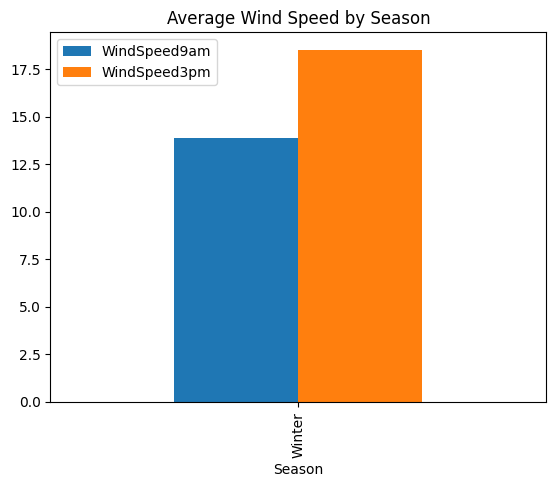

In [85]:
windspeed_by_season = rain_df.groupby('Season')[['WindSpeed9am', 'WindSpeed3pm']].mean()
windspeed_by_season.plot(kind='bar', title='Average Wind Speed by Season')
plt.show()


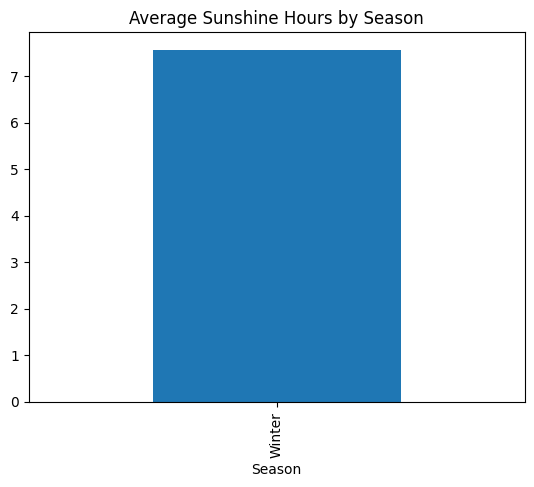

In [86]:
sunshine_by_season = rain_df.groupby('Season')['Sunshine'].mean()
sunshine_by_season.plot(kind='bar', title='Average Sunshine Hours by Season')
plt.show()


C:\Users\Morsi Store DZ\AppData\Local\Temp\ipykernel_3660\536568046.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RainTomorrow', data=rain_df, palette='Set1')


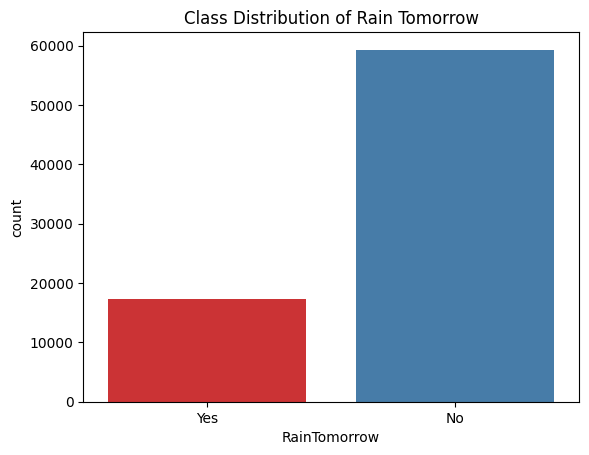

In [87]:
sns.countplot(x='RainTomorrow', data=rain_df, palette='Set1')
plt.title('Class Distribution of Rain Tomorrow')
plt.show()


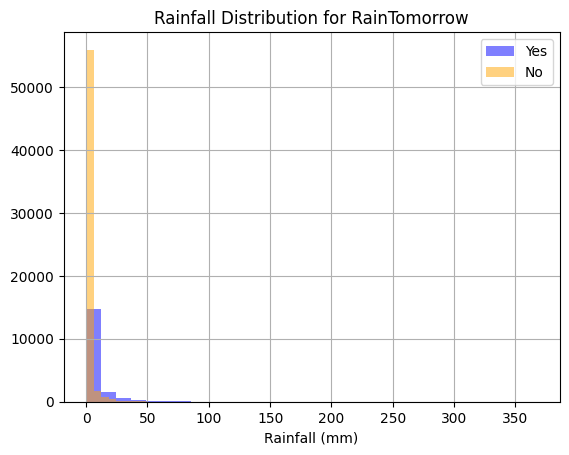

In [90]:
rain_df[rain_df['RainTomorrow'] == 'Yes']['Rainfall'].hist(bins=30, alpha=0.5, label='Yes', color='blue')
rain_df[rain_df['RainTomorrow'] == 'No']['Rainfall'].hist(bins=30, alpha=0.5, label='No', color='orange')
plt.title('Rainfall Distribution for RainTomorrow')
plt.xlabel('Rainfall (mm)')
plt.legend()
plt.show()
